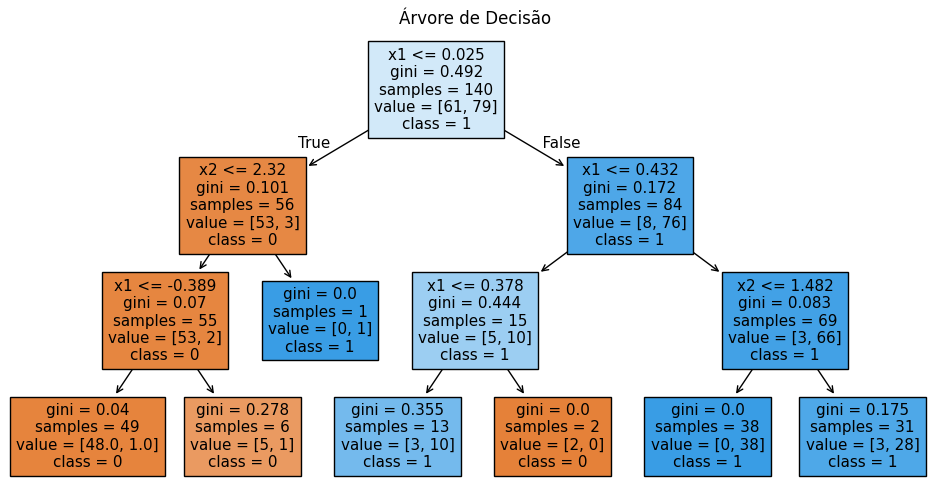

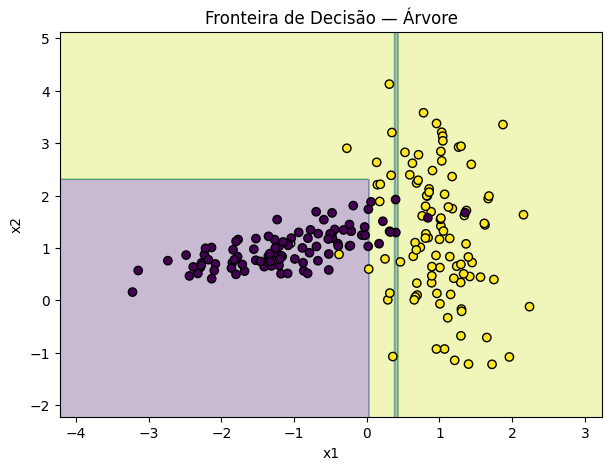

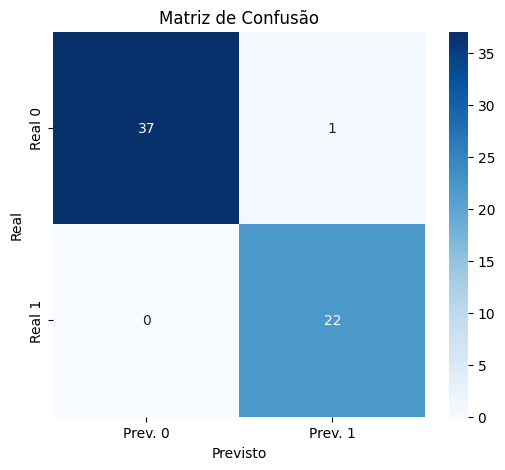

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# =====================================================
# 1) Gerar dados simples (2 classes)
# =====================================================
X, y = make_classification(n_samples=200, n_features=2,
                           n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, random_state=0)

# =====================================================
# 2) Dividir em treino e teste
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# =====================================================
# 3) Treinar a árvore
# =====================================================
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)

# =====================================================
# 4) Visualizar a Árvore
# =====================================================
plt.figure(figsize=(12,6))
plot_tree(model, filled=True, feature_names=["x1", "x2"], class_names=["0","1"])
plt.title("Árvore de Decisão")
plt.show()

# =====================================================
# 5) Fronteira de decisão
# =====================================================
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k")

plt.title("Fronteira de Decisão — Árvore")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

# =====================================================
# 6) Matriz de Confusão
# =====================================================
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Prev. 0", "Prev. 1"],
            yticklabels=["Real 0", "Real 1"])

plt.title("Matriz de Confusão")
plt.ylabel("Real")
plt.xlabel("Previsto")
plt.show()

In [3]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# =====================================================
# 7) Métricas de avaliação
# =====================================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MÉTRICAS DO MODELO")
print(f"Accuracy : {acc:.3f}")
print(f"Precisão : {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")

MÉTRICAS DO MODELO
Accuracy : 0.983
Precisão : 0.957
Recall   : 1.000
F1-score : 0.978
